In [47]:
from huggingface_hub import snapshot_download
from pathlib import Path

# 1. Route to your raw data folder
project_root = Path.cwd().parents[1]
raw_dir = project_root / "data" / "lai2023"
raw_dir.mkdir(parents=True, exist_ok=True)

# 2. Download ONLY the text/JSON files, ignoring videos
print("Downloading raw files (excluding videos)...")
snapshot_download(
    repo_id="bolinlai/Werewolf-Among-Us",
    repo_type="dataset",
    local_dir=raw_dir,
    # This tells it to skip any folder named "videos" and common video file types
    ignore_patterns=["**/videos/**", "**/*.mp4", "**/*.mkv", "**/*.webm"] 
)

print(f"Raw data saved to {raw_dir}")

Fetching 343 files:   0%|          | 0/343 [00:00<?, ?it/s]

Raw data saved to c:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023


In [1]:
from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "lai2023").exists():
            return path
    raise FileNotFoundError("Could not find project root containing data/lai2023")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "lai2023"

ANNOTATION_DIRS = {
    "yt": DATA_DIR / "Youtube" / "split",
    "ego4d": DATA_DIR / "Ego4D" / "split",
}

OUTCOME_DIRS = {
    "yt": DATA_DIR / "Youtube" / "vote_outcome_youtube_released",
    "ego4d": DATA_DIR / "Ego4D" / "vote_outcome_ego4d",
}

SPLIT_FILES = {
    dataset: {
        split: ANNOTATION_DIRS[dataset] / f"{split}.json"
        for split in ["train", "val", "test"]
    }
    for dataset in ANNOTATION_DIRS
}

In [2]:
import json

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

annot_splits = {
    dataset: {
        split: load_json(path)
        for split, path in split_map.items()
    }
    for dataset, split_map in SPLIT_FILES.items()
}

outcome_files = {
    dataset: sorted(path.glob("*.json"))
    for dataset, path in OUTCOME_DIRS.items()
}

outcome_index = {
    dataset: {
        file.stem: load_json(file)
        for file in files
    }
    for dataset, files in outcome_files.items()
}

In [3]:
print("YT outcome stems:")
print(list(outcome_index["yt"].keys())[:20])

print("\nEgo4D outcome stems:")
print(list(outcome_index["ego4d"].keys())[:20])

YT outcome stems:
['Flashback  ONE NIGHT ULTIMATE WEREWOLF  Retro 9', 'One Night Ultimate Love Letter  ONE NIGHT ULTIMATE WEREWOLF', 'ONE NIGHT ULTIMATE WEREWOLF  Retro 1', 'ONE NIGHT ULTIMATE WEREWOLF  Retro 2', 'ONE NIGHT ULTIMATE WEREWOLF  Retro 3', 'ONE NIGHT ULTIMATE WEREWOLF  Retro 4', 'ONE NIGHT ULTIMATE WEREWOLF  Retro 5', 'ONE NIGHT ULTIMATE WEREWOLF - Drinking Play Through', 'ONE NIGHT ULTIMATE WEREWOLF 1  July 5th 2016', 'One Night Ultimate Werewolf 1 How-To and Playthrough', 'ONE NIGHT ULTIMATE WEREWOLF 10  November 6th 2016', 'ONE NIGHT ULTIMATE WEREWOLF 13  July 29th 2017', 'ONE NIGHT ULTIMATE WEREWOLF 14  August 26th 2017', 'ONE NIGHT ULTIMATE WEREWOLF 18  September 30th 2017', 'One Night Ultimate Werewolf 2 The Drunk', 'ONE NIGHT ULTIMATE WEREWOLF 26  January 20th 2018', 'ONE NIGHT ULTIMATE WEREWOLF 28  February 17th 2018', 'One Night Ultimate Werewolf 3 Insomniac', 'ONE NIGHT ULTIMATE WEREWOLF 30  February 17th 2018', 'ONE NIGHT ULTIMATE WEREWOLF 34  March 24th 2018']


In [4]:
import pandas as pd
pd.DataFrame([
    {
        "YT_ID": g.get("YT_ID"),
        "video_name": g.get("video_name"),
        "Game_ID": g.get("Game_ID"),
    }
    for g in annot_splits["yt"]["train"][:10]
])

,YT_ID,video_name,Game_ID
0,part15,Way Way Back ONE NIGHT ULTIMATE WEREWOLF Ret...,Game2
1,part8,ONE NIGHT ULTIMATE WEREWOLF 13 July 29th 2017,Game2
2,part4,ONE NIGHT ULTIMATE WEREWOLF Retro 2,Game3
3,part6,ONE NIGHT ULTIMATE WEREWOLF Retro 5,Game1
4,part15,Way Way Back ONE NIGHT ULTIMATE WEREWOLF Ret...,Game4
5,part12,ONE NIGHT ULTIMATE WEREWOLF 86 November 9th 2019,Game3
6,part10,ONE NIGHT ULTIMATE WEREWOLF 43 October 13th 2018,Game1
7,part12,ONE NIGHT ULTIMATE WEREWOLF 62 March 23rd 2019,Game2
8,part5,ONE NIGHT ULTIMATE WEREWOLF Retro 4,Game5
9,part4,ONE NIGHT ULTIMATE WEREWOLF Retro 2,Game6


In [5]:
pd.DataFrame([
    {k: v for k, v in g.items() if k != "Dialogue"}
    for g in annot_splits["ego4d"]["train"][:10]
])

,EG_ID,Game_ID,playerNames,votingOutcome,startRoles,endRoles,warning
0,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game4,"[Danieal, Jessica, Kevin, Kaelan]","[NA, NA, NA, NA]","[Minion, Robber, Troublemaker, Seer]","[Robber, Seer, Troublemaker, Minion]",All players voted middle
1,62c4bc58-3776-4791-ac30-4c9ca5619503,Game10,"[Danieal, Jessica, Kevin, Kaelan]","[NA, NA, NA, NA]","[Werewolf, Villager, Minion, Villager]","[Werewolf, Villager, Minion, Villager]",All players voted middle
2,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game5,"[Danieal, Jessica, Kevin, Kaelan]","[4, NA, 2, 3]","[Robber, Tanner, Troublemaker, Drunk]","[Tanner, Troublemaker, Robber, Center Card]",Kaelans end role not mentioned. player 2 voted...
3,324bccd2-adff-4e9a-8ff4-03491e144ac3,Game1,"[Hunter, Sean, Jacob, Zack]","[0, 1, 2, 3]","[Villager, Werewolf, Villager, Troublemaker]","[Werewolf, Villager, Villager, Troublemaker]",Hunter incorrectly checks own card at end of n...
4,2ba4023c-a8bf-43ad-ad5a-80ba222ce990,Game6,"[Tyler, Margaret, Clint, Erin]","[2, 3, 2, 3]","[Drunk, Troublemaker, Werewolf, Robber]","[Werewolf, Robber, Werewolf, Drunk]",N/A
5,2ba4023c-a8bf-43ad-ad5a-80ba222ce990,Game10,"[Tyler, Margaret, Clint, Erin]","[2, 0, 3, 2]","[Werewolf, Tanner, Robber, Werewolf]","[Werewolf, Robber, Tanner, Werewolf]",N/A
6,1a0d3e22-a6d6-4723-91a0-52fc2c87d5ce,Game7,"[Hunter, Sean, Jacob, Zack]","[1, 0, 1, 1]","[Troublemaker, Seer, Robber, Werewolf]","[Robber, Werewolf, Troublemaker, Seer]",N/A
7,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game6,"[Danieal, Jessica, Kevin, Kaelan]","[NA, NA, NA, 1]","[Drunk, Insomniac, Doppelganger, Robber]","[Center card, Insomniac, Robber, Center card]",Kaelan and daniels end role not mentioned. pla...
8,62c4bc58-3776-4791-ac30-4c9ca5619503,Game11,"[Danieal, Jessica, Kevin, Kaelan]","[NA, NA, 2, 1]","[Werewolf, Minion, Villager, Villager]","[Werewolf, Minion, Villager, Villager]",Player 1 and 2 voted middle
9,1a0d3e22-a6d6-4723-91a0-52fc2c87d5ce,Game11,"[Hunter, Sean, Jacob, Zack]","[0, 3, 3, 3]","[Troublemaker, Werewolf, Drunk, Insomniac]","[Troublemaker, Werewolf, Villager, Drunk]",N/A


In [6]:
def get_session_key(game, dataset):
    if dataset == "yt":
        return game["video_name"]
    elif dataset == "ego4d":
        return game["EG_ID"]
    else:
        raise ValueError(f"Unknown dataset: {dataset}")

def get_outcome_record(game, dataset, outcome_index):
    session_key = get_session_key(game, dataset)
    game_id = game["Game_ID"]
    session_data = outcome_index[dataset][session_key]
    return session_data[game_id]

In [7]:
#sanity checks
yt_game = annot_splits["yt"]["train"][0]
yt_outcome = get_outcome_record(yt_game, "yt", outcome_index)

print("YT session key:", get_session_key(yt_game, "yt"))
print("Game_ID:", yt_game["Game_ID"])
print("Players:", yt_outcome["playerNames"])
print("Votes:", yt_outcome["votingOutcome"])
print("Roles:", yt_outcome["startRoles"])

YT session key: Way Way Back  ONE NIGHT ULTIMATE WEREWOLF  Retro 10
Game_ID: Game2
Players: ['Justin', 'Laura', 'Paul', 'James', 'Mitchell']
Votes: [1, 2, 1, 0, 1]
Roles: ['Tanner', 'Troublemaker', 'Werewolf', 'Villager', 'Seer']


In [8]:
ego_game = annot_splits["ego4d"]["train"][0]
ego_outcome = get_outcome_record(ego_game, "ego4d", outcome_index)

print("Ego session key:", get_session_key(ego_game, "ego4d"))
print("Game_ID:", ego_game["Game_ID"])
print("Players:", ego_outcome["playerNames"])
print("Votes:", ego_outcome["votingOutcome"])
print("Roles:", ego_outcome["startRoles"])

Ego session key: 3ba069be-60fa-47fc-bd7b-f85bf649a5bd
Game_ID: Game4
Players: ['Kevin', 'Kaelan', 'Jessica', 'Daniel']
Votes: ['NA', 'NA', 'NA', 'NA']
Roles: ['Troublemaker', 'Seer', 'Robber', 'Minion']


### Replicate Lai et al. voting outcome experiment

In [9]:
#start building voting outcome model
STRATEGIES = [
    "No Strategy",
    "Identity Declaration",
    "Accusation",
    "Interrogation",
    "Call for Action",
    "Defense",
    "Evidence",
]

In [10]:
from collections import Counter

def compute_player_strategy_counts(dialogue, players, strategies=STRATEGIES):
    counts = {player: Counter({s: 0 for s in strategies}) for player in players}

    for rec in dialogue:
        speaker = rec["speaker"]
        if speaker not in counts:
            continue
        for label in rec["annotation"]:
            if label in strategies:
                counts[speaker][label] += 1

    return counts

def normalize_strategy_counts(counts, strategies=STRATEGIES):
    dists = {}
    for player, cnt in counts.items():
        total = sum(cnt[s] for s in strategies)
        if total == 0:
            dists[player] = {s: 0.0 for s in strategies}
        else:
            dists[player] = {s: cnt[s] / total for s in strategies}
    return dists

In [11]:
#test
counts = compute_player_strategy_counts(yt_game["Dialogue"], yt_outcome["playerNames"])
dists = normalize_strategy_counts(counts)

pd.DataFrame(dists).T

,No Strategy,Identity Declaration,Accusation,Interrogation,Call for Action,Defense,Evidence
Justin,0.311111,0.088889,0.288889,0.133333,0.111111,0.044444,0.022222
Laura,0.407407,0.000000,0.148148,0.185185,0.037037,0.185185,0.037037
Paul,0.421053,0.000000,0.131579,0.184211,0.026316,0.184211,0.052632
James,0.392857,0.071429,0.107143,0.214286,0.071429,0.071429,0.071429
Mitchell,0.404762,0.023810,0.142857,0.166667,0.047619,0.071429,0.142857


In [12]:
ROLE_LIST = [
    "Villager",
    "Werewolf",
    "Seer",
    "Robber",
    "Troublemaker",
    "Tanner",
    "Drunk",
    "Hunter",
    "Mason",
    "Insomniac",
    "Minion",
    "Doppelganger",
]

def one_hot_role(role, role_list=ROLE_LIST):
    return [1 if role == r else 0 for r in role_list]

In [13]:
def build_pairwise_rows(game, dataset, outcome_index, include_roles=True):
    outcome = get_outcome_record(game, dataset, outcome_index)
    players = outcome["playerNames"]
    start_roles = outcome["startRoles"]
    voting_outcome = outcome["votingOutcome"]
    dialogue = game["Dialogue"]

    role_map = dict(zip(players, start_roles))

    counts = compute_player_strategy_counts(dialogue, players)
    dists = normalize_strategy_counts(counts)

    rows = []
    for i, voter in enumerate(players):
        for j, candidate in enumerate(players):
            label = 1 if voting_outcome[i] == j else 0

            feature = (
                [dists[voter][s] for s in STRATEGIES] +
                [dists[candidate][s] for s in STRATEGIES]
            )

            if include_roles:
                feature += one_hot_role(role_map[voter])

            rows.append({
                "dataset": dataset,
                "session_key": get_session_key(game, dataset),
                "game_id": game["Game_ID"],
                "voter": voter,
                "candidate": candidate,
                "label": label,
                "feature": feature,
            })

    return rows

In [14]:
#test
rows = build_pairwise_rows(yt_game, "yt", outcome_index)
len(rows), rows[0]["voter"], rows[0]["candidate"], rows[0]["label"], len(rows[0]["feature"])

(25, 'Justin', 'Justin', 0, 26)

In [15]:
set(len(r["feature"]) for r in rows)

{26}

In [16]:
def build_split_rows(games, dataset, outcome_index, include_roles=True):
    all_rows = []
    for game in games:
        all_rows.extend(build_pairwise_rows(game, dataset, outcome_index, include_roles=include_roles))
    return all_rows

In [17]:
yt_train_rows = build_split_rows(annot_splits["yt"]["train"], "yt", outcome_index)
ego_train_rows = build_split_rows(annot_splits["ego4d"]["train"], "ego4d", outcome_index)

print("YT train rows:", len(yt_train_rows))
print("Ego4D train rows:", len(ego_train_rows))
#same split as in paper
print("Combined train rows:", len(yt_train_rows) + len(ego_train_rows))

YT train rows: 2153
Ego4D train rows: 588
Combined train rows: 2741


In [18]:
train_rows = (
    build_split_rows(annot_splits["yt"]["train"], "yt", outcome_index) +
    build_split_rows(annot_splits["ego4d"]["train"], "ego4d", outcome_index)
)

val_rows = (
    build_split_rows(annot_splits["yt"]["val"], "yt", outcome_index) +
    build_split_rows(annot_splits["ego4d"]["val"], "ego4d", outcome_index)
)

test_rows = (
    build_split_rows(annot_splits["yt"]["test"], "yt", outcome_index) +
    build_split_rows(annot_splits["ego4d"]["test"], "ego4d", outcome_index)
)

In [19]:
#players
from collections import Counter

def extract_player_and_group_stats(annot_splits):
    all_players = set()
    group_counter = Counter()
    game_counter = 0

    for dataset, split_map in annot_splits.items():
        for split, games in split_map.items():
            for game in games:
                game_counter += 1

                outcome = get_outcome_record(game, dataset, outcome_index)
                players = outcome["playerNames"]

                # unique players overall
                all_players.update(players)

                # unique group identity = sorted tuple of names
                group_key = tuple(sorted(players))
                group_counter[group_key] += 1

    return all_players, group_counter, game_counter

In [20]:
all_players, group_counter, total_games = extract_player_and_group_stats(annot_splits)

print("Total games:", total_games)
print("Unique player names:", len(all_players))
print("Unique groups:", len(group_counter))

Total games: 191
Unique player names: 60
Unique groups: 36


In [21]:
group_df = pd.DataFrame([
    {
        "group_size": len(group),
        "num_games": count,
        "players": ", ".join(group)
    }
    for group, count in group_counter.items()
]).sort_values(["num_games", "group_size"], ascending=[False, False])

group_df.head(20)

,group_size,num_games,players
4,4,18,"Justin, Mike, Mitchell, Paul"
0,5,15,"James, Justin, Laura, Mitchell, Paul"
6,5,12,"Caitlynn, James, Justin, Mike, Mitchell"
31,4,12,"Daniel, Jessica, Kaelan, Kevin"
32,4,11,"Hunter, Jacob, Sean, Zack"
10,4,10,"Alana, Caitlynn, Mike, Mitchell"
15,4,10,"Alvin, James, Justin, Mitchell"
34,6,9,"Ashley, Chris, Elliot, James, Sian, Sukeshi"
7,5,9,"Eric, Justin, Mike, Mitchell, Paul"
2,5,8,"Caitlynn, Dan, Justin, Mike, Mitchell"


In [22]:
import numpy as np

def rows_to_xy(rows):
    X = np.array([r["feature"] for r in rows], dtype=np.float32)
    y = np.array([r["label"] for r in rows], dtype=np.int64)
    return X, y

X_train, y_train = rows_to_xy(train_rows)
X_val, y_val = rows_to_xy(val_rows)
X_test, y_test = rows_to_xy(test_rows)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2741, 26) (2741,)
(445, 26) (445,)
(836, 26) (836,)


In [23]:
print("Feature dims:", X_train.shape[1])
print("Train positive rate:", y_train.mean())
print("Val positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Feature dims: 26
Train positive rate: 0.20977745348412988
Val positive rate: 0.20449438202247192
Test positive rate: 0.18181818181818182


In [ ]:


# Build datasets without role features
train_rows_no_roles = (
    build_split_rows(annot_splits["yt"]["train"], "yt", outcome_index, include_roles=False) +
    build_split_rows(annot_splits["ego4d"]["train"], "ego4d", outcome_index, include_roles=False)
)

val_rows_no_roles = (
    build_split_rows(annot_splits["yt"]["val"], "yt", outcome_index, include_roles=False) +
    build_split_rows(annot_splits["ego4d"]["val"], "ego4d", outcome_index, include_roles=False)
)

test_rows_no_roles = (
    build_split_rows(annot_splits["yt"]["test"], "yt", outcome_index, include_roles=False) +
    build_split_rows(annot_splits["ego4d"]["test"], "ego4d", outcome_index, include_roles=False)
)

# Convert to arrays
X_train_nr, y_train_nr = rows_to_xy(train_rows_no_roles)
X_val_nr, y_val_nr = rows_to_xy(val_rows_no_roles)
X_test_nr, y_test_nr = rows_to_xy(test_rows_no_roles)

print("No-role shapes:")
print(X_train_nr.shape, y_train_nr.shape)
print(X_val_nr.shape, y_val_nr.shape)
print(X_test_nr.shape, y_test_nr.shape)


No-role shapes:
(2741, 14) (2741,)
(445, 14) (445,)
(836, 14) (836,)


In [48]:
# paper-faithful logistic regression

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

def _get_feature_names(include_roles, strategies=STRATEGIES, role_list=ROLE_LIST):
    names = [f"voter_{s}" for s in strategies] + [f"candidate_{s}" for s in strategies]
    if include_roles:
        names += [f"role_{r}" for r in role_list]
    return names

def _select_split_arrays(include_roles):
    if include_roles:
        return X_train, y_train, X_val, y_val, X_test, y_test
    return X_train_nr, y_train_nr, X_val_nr, y_val_nr, X_test_nr, y_test_nr

def run_logreg_paper_exact(include_roles=True):
    """
    Mirrors the repository code as closely as possible for logistic regression:
    - strategy-only: class_weight={0:1.0, 1:4.2}, C=1.4
    - with roles:    class_weight={0:1.0, 1:4.8}, C=0.8
    - uses predict()
    - computes AUC on hard predictions, exactly like their script
    """
    X_tr, y_tr, X_val, y_val, X_te, y_te = _select_split_arrays(include_roles)

    if include_roles:
        class_weight = {0: 1.0, 1: 4.8}
        C = 0.8
    else:
        class_weight = {0: 1.0, 1: 4.2}
        C = 1.4

    model = LogisticRegression(
        class_weight=class_weight,
        C=C,
        max_iter=2000,
        random_state=42
    )
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_te)

    train_metrics = {
        "f1": f1_score(y_tr, train_pred),
        "auc_hard": roc_auc_score(y_tr, train_pred),
        "accuracy": accuracy_score(y_tr, train_pred),
        "positive_rate": y_tr.mean(),
    }
    val_metrics = {
        "f1": f1_score(y_val, val_pred),
        "auc_hard": roc_auc_score(y_val, val_pred),
        "accuracy": accuracy_score(y_val, val_pred),
        "positive_rate": y_val.mean(),
    }
    test_metrics = {
        "f1": f1_score(y_te, test_pred),
        "auc_hard": roc_auc_score(y_te, test_pred),
        "accuracy": accuracy_score(y_te, test_pred),
        "positive_rate": y_te.mean(),
    }

    feature_names = _get_feature_names(include_roles)
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": model.coef_[0]
    }).sort_values("coef", ascending=False)

    return {
        "include_roles": include_roles,
        "C": C,
        "class_weight": class_weight,
        "model": model,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "coef_df": coef_df,
        "train_pred": train_pred,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

In [49]:
paper_strat = run_logreg_paper_exact(include_roles=False)
paper_full = run_logreg_paper_exact(include_roles=True)

In [50]:
comparison = pd.DataFrame([
    {
        "model": "paper exact - strategies only",
        "roles": False,
        "f1": paper_strat["test_metrics"]["f1"],
        "auc": paper_strat["test_metrics"]["auc_hard"],
    },
    {
        "model": "paper exact - strategies + role",
        "roles": True,
        "f1": paper_full["test_metrics"]["f1"],
        "auc": paper_full["test_metrics"]["auc_hard"],
    },
])

comparison

,model,roles,f1,auc
0,paper exact - strategies only,False,0.323288,0.551901
1,paper exact - strategies + role,True,0.323810,0.543860


### Interpretation of regression coefficients

In [51]:
coef_df_no_roles = paper_strat["coef_df"]

In [52]:
import matplotlib.pyplot as plt
import numpy as np

def plot_figure6_paper_like(
    coef_df_no_roles,
    color_zero="#8ecae6",
    color_one="#f4a261",
    min_alpha=0.12,
    max_alpha=0.95,
    linewidth=1.8,
    gamma=1.0,
):
    strategies = [
        "No Strategy",
        "Identity Declaration",
        "Accusation",
        "Interrogation",
        "Call for Action",
        "Defense",
        "Evidence",
    ]

    coef_map = dict(zip(coef_df_no_roles["feature"], coef_df_no_roles["coef"]))

    voter_feats = [f"voter_{s}" for s in strategies]
    cand_feats = [f"candidate_{s}" for s in strategies]

    voter_coefs = [coef_map.get(f, 0.0) for f in voter_feats]
    cand_coefs = [coef_map.get(f, 0.0) for f in cand_feats]

    y_positions = np.linspace(0.82, 0.18, len(strategies))
    x_voter = 0.18
    x_candidate = 0.82
    x_center = 0.50
    y_zero = 0.58
    y_one = 0.42

    fig, ax = plt.subplots(figsize=(7.4, 3.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # headers
    ax.text(x_voter, 0.93, "Voter", ha="center", va="center",
            fontsize=14, fontweight="bold", color="#5f6f7f")
    ax.text(x_candidate, 0.93, "Candidate", ha="center", va="center",
            fontsize=14, fontweight="bold", color="#5f6f7f")

    # dashed header lines
    ax.plot([0.05, 0.33], [0.91, 0.91], ls="--", lw=1.2, color="gray", alpha=0.8)
    ax.plot([0.67, 0.95], [0.91, 0.91], ls="--", lw=1.2, color="gray", alpha=0.8)

    # outcome labels
    ax.text(x_center, 0.79, "The voter doesn’t vote\nfor the candidate",
            ha="center", va="center", fontsize=11, color=color_zero)
    ax.text(x_center, 0.21, "The voter votes\nfor the candidate",
            ha="center", va="center", fontsize=11, color=color_one)

    # strategy labels: plain text, no boxes
    for y, s in zip(y_positions, strategies):
        ax.text(x_voter, y, s, ha="center", va="center", fontsize=12)
        ax.text(x_candidate, y, s, ha="center", va="center", fontsize=12)

    # 0 / 1 nodes
    ax.text(x_center, y_zero, "0", ha="center", va="center", fontsize=16,
            bbox=dict(boxstyle="circle,pad=0.30", fc="white", ec="black", lw=1.2))
    ax.text(x_center, y_one, "1", ha="center", va="center", fontsize=16,
            bbox=dict(boxstyle="circle,pad=0.30", fc="white", ec="black", lw=1.2))

    all_coefs = np.array(voter_coefs + cand_coefs, dtype=float)
    max_abs = np.max(np.abs(all_coefs)) if len(all_coefs) else 1.0
    if max_abs == 0:
        max_abs = 1.0

    def alpha_from_coef(coef):
        mag = abs(coef) / max_abs
        mag = mag ** gamma
        return min_alpha + (max_alpha - min_alpha) * mag

    def draw_edges(x_source, ys, coefs):
        x_start = x_source + (0.07 if x_source < x_center else -0.07)

        for y, coef in zip(ys, coefs):
            alpha = alpha_from_coef(coef)
            if coef >= 0:
                ax.plot([x_start, x_center], [y, y_one],
                        color=color_one, alpha=alpha, lw=linewidth)
            else:
                ax.plot([x_start, x_center], [y, y_zero],
                        color=color_zero, alpha=alpha, lw=linewidth)

    draw_edges(x_voter, y_positions, voter_coefs)
    draw_edges(x_candidate, y_positions, cand_coefs)

    plt.tight_layout()
    plt.show()

In [53]:
coef_df_no_roles

,feature,coef
11,candidate_Call for Action,1.944057
8,candidate_Identity Declaration,1.274154
12,candidate_Defense,0.890622
6,voter_Evidence,0.871672
3,voter_Interrogation,0.850130
2,voter_Accusation,0.756514
0,voter_No Strategy,0.552654
10,candidate_Interrogation,0.517724
7,candidate_No Strategy,0.431728
4,voter_Call for Action,0.186772


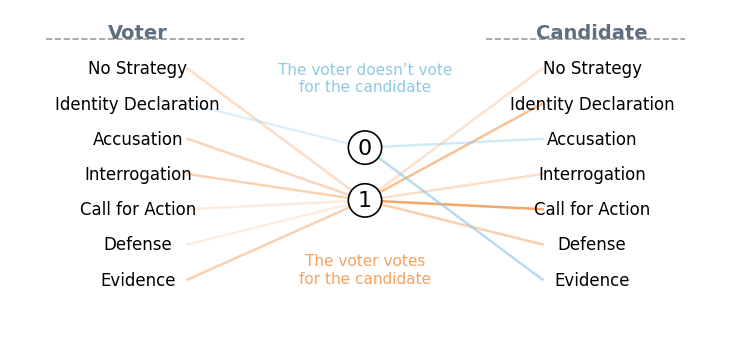

In [54]:
plot_figure6_paper_like(coef_df_no_roles)

In [55]:
# Cell 1 — Build early/late temporal dataset

from collections import Counter, defaultdict
import numpy as np

def compute_player_early_late_dists(dialogue, players, strategies=STRATEGIES):
    """
    For each player, split their utterances into first half / second half
    according to utterance order within that player's own turns.
    Then compute normalized strategy distributions for each half.
    """
    player_utts = defaultdict(list)

    for rec in dialogue:
        speaker = rec["speaker"]
        if speaker in players:
            player_utts[speaker].append(rec)

    def zero_dist():
        return {s: 0.0 for s in strategies}

    def normalize_counter(counter):
        total = sum(counter[s] for s in strategies)
        if total == 0:
            return zero_dist()
        return {s: counter[s] / total for s in strategies}

    early_dists = {}
    late_dists = {}

    for player in players:
        utts = player_utts[player]
        n = len(utts)
        split_idx = n // 2  # first half / second half

        early_utts = utts[:split_idx]
        late_utts = utts[split_idx:]

        early_counter = Counter({s: 0 for s in strategies})
        late_counter = Counter({s: 0 for s in strategies})

        for rec in early_utts:
            for label in rec["annotation"]:
                if label in strategies:
                    early_counter[label] += 1

        for rec in late_utts:
            for label in rec["annotation"]:
                if label in strategies:
                    late_counter[label] += 1

        early_dists[player] = normalize_counter(early_counter)
        late_dists[player] = normalize_counter(late_counter)

    return early_dists, late_dists


def build_pairwise_rows_temporal(game, dataset, outcome_index):
    outcome = get_outcome_record(game, dataset, outcome_index)

    players = outcome["playerNames"]
    voting_outcome = outcome["votingOutcome"]
    dialogue = game["Dialogue"]

    early_dists, late_dists = compute_player_early_late_dists(dialogue, players)

    rows = []
    for i, voter in enumerate(players):
        for j, candidate in enumerate(players):
            label = 1 if voting_outcome[i] == j else 0

            feature = (
                [early_dists[voter][s] for s in STRATEGIES] +
                [late_dists[voter][s] for s in STRATEGIES] +
                [early_dists[candidate][s] for s in STRATEGIES] +
                [late_dists[candidate][s] for s in STRATEGIES]
            )

            rows.append({
                "dataset": dataset,
                "session_key": get_session_key(game, dataset),
                "game_id": game["Game_ID"],
                "voter": voter,
                "candidate": candidate,
                "label": label,
                "feature": feature,
            })

    return rows


def build_split_rows_temporal(games, dataset, outcome_index):
    all_rows = []
    for game in games:
        all_rows.extend(build_pairwise_rows_temporal(game, dataset, outcome_index))
    return all_rows


def rows_to_xy(rows):
    X = np.array([r["feature"] for r in rows], dtype=np.float32)
    y = np.array([r["label"] for r in rows], dtype=np.int64)
    return X, y


def get_temporal_feature_names():
    return (
        [f"voter_early_{s}" for s in STRATEGIES] +
        [f"voter_late_{s}" for s in STRATEGIES] +
        [f"candidate_early_{s}" for s in STRATEGIES] +
        [f"candidate_late_{s}" for s in STRATEGIES]
    )


# Build temporal train/val/test
train_rows_temp = (
    build_split_rows_temporal(annot_splits["yt"]["train"], "yt", outcome_index) +
    build_split_rows_temporal(annot_splits["ego4d"]["train"], "ego4d", outcome_index)
)
val_rows_temp = (
    build_split_rows_temporal(annot_splits["yt"]["val"], "yt", outcome_index) +
    build_split_rows_temporal(annot_splits["ego4d"]["val"], "ego4d", outcome_index)
)
test_rows_temp = (
    build_split_rows_temporal(annot_splits["yt"]["test"], "yt", outcome_index) +
    build_split_rows_temporal(annot_splits["ego4d"]["test"], "ego4d", outcome_index)
)

X_train_temp, y_train_temp = rows_to_xy(train_rows_temp)
X_val_temp, y_val_temp = rows_to_xy(val_rows_temp)
X_test_temp, y_test_temp = rows_to_xy(test_rows_temp)

feature_names_temp = get_temporal_feature_names()

print("Temporal model shapes:", X_train_temp.shape, X_val_temp.shape, X_test_temp.shape)

Temporal model shapes: (2741, 28) (445, 28) (836, 28)


In [62]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


def eval_prob_model(model, X, y, threshold):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "f1": f1_score(y, y_pred, zero_division=0),
        "auc_prob": roc_auc_score(y, y_prob),
        "accuracy": accuracy_score(y, y_pred),
        "positive_rate": y.mean(),
        "predicted_positive_rate": y_pred.mean(),
    }, y_prob, y_pred


def run_tuned_logreg_with_classweight_search(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    feature_names,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0, 5.0),
    class_weight_grid=(None, "balanced", {0:1, 1:2}, {0:1, 1:3}, {0:1, 1:4}, {0:1, 1:5}),
    solver="liblinear",
):
    search_rows = []
    best = None

    for cw in class_weight_grid:
        for C in c_grid:
            model = LogisticRegression(
                class_weight=cw,
                C=C,
                max_iter=3000,
                random_state=42,
                solver=solver
            )
            model.fit(X_train, y_train)

            val_prob = model.predict_proba(X_val)[:, 1]
            best_t, best_val_f1 = find_best_threshold(y_val, val_prob)
            val_auc = roc_auc_score(y_val, val_prob)

            search_rows.append({
                "C": C,
                "class_weight": str(cw),
                "val_best_threshold": best_t,
                "val_f1": best_val_f1,
                "val_auc_prob": val_auc,
            })

            if best is None or (best_val_f1 > best["val_f1"]) or (
                np.isclose(best_val_f1, best["val_f1"]) and val_auc > best["val_auc_prob"]
            ):
                best = {
                    "C": C,
                    "class_weight": cw,
                    "threshold": best_t,
                    "val_f1": best_val_f1,
                    "val_auc_prob": val_auc,
                    "model": model,
                }

    best_model = best["model"]
    best_threshold = best["threshold"]

    train_metrics, train_prob, train_pred = eval_prob_model(best_model, X_train, y_train, best_threshold)
    val_metrics, val_prob, val_pred = eval_prob_model(best_model, X_val, y_val, best_threshold)
    test_metrics, test_prob, test_pred = eval_prob_model(best_model, X_test, y_test, best_threshold)

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": best_model.coef_[0]
    }).sort_values("coef", ascending=False)

    search_df = pd.DataFrame(search_rows).sort_values(
        ["val_f1", "val_auc_prob"], ascending=False
    ).reset_index(drop=True)

    return {
        "best_C": best["C"],
        "best_class_weight": best["class_weight"],
        "best_threshold": best_threshold,
        "model": best_model,
        "search_df": search_df,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "coef_df": coef_df,
        "train_prob": train_prob,
        "val_prob": val_prob,
        "test_prob": test_prob,
        "train_pred": train_pred,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

In [63]:
res_temp = run_tuned_logreg_with_classweight_search(
    X_train_temp, y_train_temp,
    X_val_temp, y_val_temp,
    X_test_temp, y_test_temp,
    feature_names_temp,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0),
    class_weight_grid=(
        None,
        "balanced",
        {0:1, 1:1.5},
        {0:1, 1:2},
        {0:1, 1:3},
        {0:1, 1:4},
        {0:1, 1:5},
    ),
    solver="liblinear",
)

In [64]:
print("Best C:", res_temp["best_C"])
print("Best class_weight:", res_temp["best_class_weight"])
print("Best threshold:", res_temp["best_threshold"])
print("Validation F1:", res_temp["val_metrics"]["f1"])
print("Test F1:", res_temp["test_metrics"]["f1"])
print("Test AUC:", res_temp["test_metrics"]["auc_prob"])

Best C: 0.1
Best class_weight: {0: 1, 1: 4}
Best threshold: 0.49
Validation F1: 0.35294117647058826
Test F1: 0.3333333333333333
Test AUC: 0.5802362265312404


In [65]:
coef_df_temp = res_temp["coef_df"]
coef_df_temp.sort_values("coef", ascending=False)

,feature,coef
25,candidate_late_Call for Action,0.846045
17,candidate_early_Interrogation,0.374611
14,candidate_early_No Strategy,0.335490
19,candidate_early_Defense,0.293314
10,voter_late_Interrogation,0.256939
15,candidate_early_Identity Declaration,0.218808
26,candidate_late_Defense,0.211122
13,voter_late_Evidence,0.197467
2,voter_early_Accusation,0.191422
3,voter_early_Interrogation,0.161898


In [66]:
# Cell — Build candidate-only temporal dataset

from collections import Counter, defaultdict
import numpy as np

def compute_player_early_late_dists(dialogue, players, strategies=STRATEGIES):
    player_utts = defaultdict(list)

    for rec in dialogue:
        speaker = rec["speaker"]
        if speaker in players:
            player_utts[speaker].append(rec)

    def zero_dist():
        return {s: 0.0 for s in strategies}

    def normalize_counter(counter):
        total = sum(counter[s] for s in strategies)
        if total == 0:
            return zero_dist()
        return {s: counter[s] / total for s in strategies}

    early_dists = {}
    late_dists = {}

    for player in players:
        utts = player_utts[player]
        n = len(utts)
        split_idx = n // 2

        early_utts = utts[:split_idx]
        late_utts = utts[split_idx:]

        early_counter = Counter({s: 0 for s in strategies})
        late_counter = Counter({s: 0 for s in strategies})

        for rec in early_utts:
            for label in rec["annotation"]:
                if label in strategies:
                    early_counter[label] += 1

        for rec in late_utts:
            for label in rec["annotation"]:
                if label in strategies:
                    late_counter[label] += 1

        early_dists[player] = normalize_counter(early_counter)
        late_dists[player] = normalize_counter(late_counter)

    return early_dists, late_dists


def build_pairwise_rows_temporal_candidate_only(game, dataset, outcome_index):
    outcome = get_outcome_record(game, dataset, outcome_index)

    players = outcome["playerNames"]
    voting_outcome = outcome["votingOutcome"]
    dialogue = game["Dialogue"]

    early_dists, late_dists = compute_player_early_late_dists(dialogue, players)

    rows = []
    for i, voter in enumerate(players):
        for j, candidate in enumerate(players):
            label = 1 if voting_outcome[i] == j else 0

            feature = (
                [early_dists[candidate][s] for s in STRATEGIES] +
                [late_dists[candidate][s] for s in STRATEGIES]
            )

            rows.append({
                "dataset": dataset,
                "session_key": get_session_key(game, dataset),
                "game_id": game["Game_ID"],
                "voter": voter,
                "candidate": candidate,
                "label": label,
                "feature": feature,
            })

    return rows


def build_split_rows_temporal_candidate_only(games, dataset, outcome_index):
    all_rows = []
    for game in games:
        all_rows.extend(build_pairwise_rows_temporal_candidate_only(game, dataset, outcome_index))
    return all_rows


def rows_to_xy(rows):
    X = np.array([r["feature"] for r in rows], dtype=np.float32)
    y = np.array([r["label"] for r in rows], dtype=np.int64)
    return X, y


def get_temporal_candidate_only_feature_names():
    return (
        [f"candidate_early_{s}" for s in STRATEGIES] +
        [f"candidate_late_{s}" for s in STRATEGIES]
    )

In [67]:
train_rows_temp_cand = (
    build_split_rows_temporal_candidate_only(annot_splits["yt"]["train"], "yt", outcome_index) +
    build_split_rows_temporal_candidate_only(annot_splits["ego4d"]["train"], "ego4d", outcome_index)
)
val_rows_temp_cand = (
    build_split_rows_temporal_candidate_only(annot_splits["yt"]["val"], "yt", outcome_index) +
    build_split_rows_temporal_candidate_only(annot_splits["ego4d"]["val"], "ego4d", outcome_index)
)
test_rows_temp_cand = (
    build_split_rows_temporal_candidate_only(annot_splits["yt"]["test"], "yt", outcome_index) +
    build_split_rows_temporal_candidate_only(annot_splits["ego4d"]["test"], "ego4d", outcome_index)
)

X_train_temp_cand, y_train_temp_cand = rows_to_xy(train_rows_temp_cand)
X_val_temp_cand, y_val_temp_cand = rows_to_xy(val_rows_temp_cand)
X_test_temp_cand, y_test_temp_cand = rows_to_xy(test_rows_temp_cand)

feature_names_temp_cand = get_temporal_candidate_only_feature_names()

print("Candidate-only temporal model shapes:",
      X_train_temp_cand.shape, X_val_temp_cand.shape, X_test_temp_cand.shape)

Candidate-only temporal model shapes: (2741, 14) (445, 14) (836, 14)


In [68]:
res_temp_cand = run_tuned_logreg_with_classweight_search(
    X_train_temp_cand, y_train_temp_cand,
    X_val_temp_cand, y_val_temp_cand,
    X_test_temp_cand, y_test_temp_cand,
    feature_names_temp_cand,
    c_grid=(0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4, 2.0, 3.0),
    class_weight_grid=(
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5},
    ),
    solver="liblinear",
)

In [69]:
comparison_models = pd.DataFrame([
    {
        "model": "Temporal full",
        "features": X_test_temp.shape[1],
        "best_C": res_temp["best_C"],
        "best_class_weight": str(res_temp["best_class_weight"]),
        "threshold": res_temp["test_metrics"]["threshold"],
        "test_f1": res_temp["test_metrics"]["f1"],
        "test_auc": res_temp["test_metrics"]["auc_prob"],
    },
    {
        "model": "Temporal candidate only",
        "features": X_test_temp_cand.shape[1],
        "best_C": res_temp_cand["best_C"],
        "best_class_weight": str(res_temp_cand["best_class_weight"]),
        "threshold": res_temp_cand["test_metrics"]["threshold"],
        "test_f1": res_temp_cand["test_metrics"]["f1"],
        "test_auc": res_temp_cand["test_metrics"]["auc_prob"],
    },
])

comparison_models

,model,features,best_C,best_class_weight,threshold,test_f1,test_auc
0,Temporal full,28,0.1,"{0: 1, 1: 4}",0.49,0.333333,0.580236
1,Temporal candidate only,14,3.0,"{0: 1, 1: 5}",0.55,0.340299,0.571277


In [72]:
coef_df_temp = res_temp_cand["coef_df"]
print(coef_df_temp.sort_values("coef", ascending=False))

                                 feature      coef
11        candidate_late_Call for Action  1.644647
3          candidate_early_Interrogation  0.951445
5                candidate_early_Defense  0.902276
0            candidate_early_No Strategy  0.765162
1   candidate_early_Identity Declaration  0.760442
8    candidate_late_Identity Declaration  0.495747
12                candidate_late_Defense  0.451424
2             candidate_early_Accusation  0.199737
7             candidate_late_No Strategy  0.068264
10          candidate_late_Interrogation  0.031624
9              candidate_late_Accusation -0.243766
13               candidate_late_Evidence -0.378506
4        candidate_early_Call for Action -0.667147
6               candidate_early_Evidence -0.764115
